In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LIBRARIES

In [45]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torchvision.models import EfficientNet_B0_Weights
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt

INPUTS

In [46]:
IMG_HEIGHT=224
IMG_WIDTH =224
IMG_CHANNELS=3
CLASS_NAMES=["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [47]:
transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dir ="/content/drive/MyDrive/flower_images/train"
val_dir = "/content/drive/MyDrive/flower_images/val"

train_data= datasets.ImageFolder(root=train_dir, transform=transform)
val_data= datasets.ImageFolder(root=val_dir, transform = val_transform)

train_dataset = DataLoader(train_data, batch_size=16, shuffle=True)
val_dataset = DataLoader(val_data, batch_size = 16)

NETWORK ARCHITECTURE

In [48]:
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad=False

model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, len(CLASS_NAMES))

for param in model.classifier[-1].parameters():
    param.requires_grad=True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [50]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    train_loss= []
    train_acc=[]
    val_loss =[]
    val_acc=[]
    for epoch in range(epochs):
        model.train()
        correct_preds =0
        total_loss =0
        total_samples =0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs= model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct_preds +=(preds==labels).sum().item()
            total_loss += loss.item()
            total_samples += labels.size(0)
        acc = correct_preds/total_samples
        print(f"Epoch {epoch+1}: Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")
        train_loss.append(total_loss)
        train_acc.append(acc)

        model.eval()
        with torch.no_grad():
            eval_preds =0
            eval_loss =0
            eval_samples=0
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)

                eval_preds +=(preds==labels).sum().item()
                eval_loss += loss.item()
                eval_samples += labels.size(0)
            eval_acc =eval_preds/eval_samples
            print(f" Validation Loss: {eval_loss:.4f}, Validation Accuracy: {eval_acc:.4f}")
            val_loss.append(eval_loss)
            val_acc.append(eval_acc)

    return train_loss, train_acc, val_loss, val_acc

TRAINING

In [51]:
EPOCHS =10
train_loss, train_acc, val_loss, val_acc= train_model(model, criterion, optimizer, train_dataset, val_dataset, EPOCHS, device)

Epoch 1: Loss: 157.8204, Accuracy: 0.7410
 Validation Loss: 30.8904, Validation Accuracy: 0.8700
Epoch 2: Loss: 96.3326, Accuracy: 0.8340
 Validation Loss: 25.2476, Validation Accuracy: 0.8800
Epoch 3: Loss: 86.2707, Accuracy: 0.8413
 Validation Loss: 22.4871, Validation Accuracy: 0.8980
Epoch 4: Loss: 79.8892, Accuracy: 0.8537
 Validation Loss: 21.8010, Validation Accuracy: 0.9000
Epoch 5: Loss: 74.2272, Accuracy: 0.8620
 Validation Loss: 19.9233, Validation Accuracy: 0.9150
Epoch 6: Loss: 70.0091, Accuracy: 0.8710
 Validation Loss: 18.4914, Validation Accuracy: 0.9160
Epoch 7: Loss: 68.0560, Accuracy: 0.8783
 Validation Loss: 18.7216, Validation Accuracy: 0.9110
Epoch 8: Loss: 70.0101, Accuracy: 0.8703
 Validation Loss: 19.0857, Validation Accuracy: 0.9140
Epoch 9: Loss: 62.4367, Accuracy: 0.8890
 Validation Loss: 19.0119, Validation Accuracy: 0.8990
Epoch 10: Loss: 61.4434, Accuracy: 0.8850
 Validation Loss: 19.0616, Validation Accuracy: 0.9140


PLOTTING

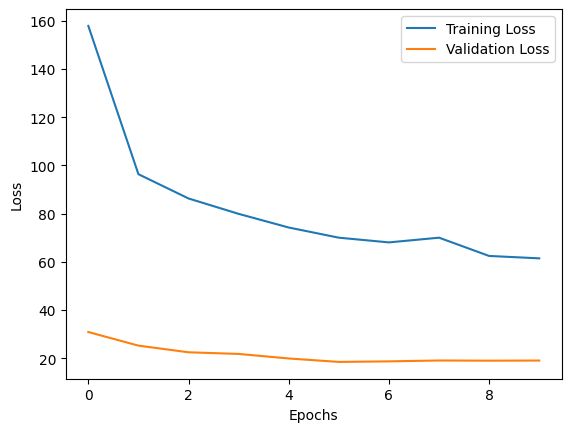

In [52]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

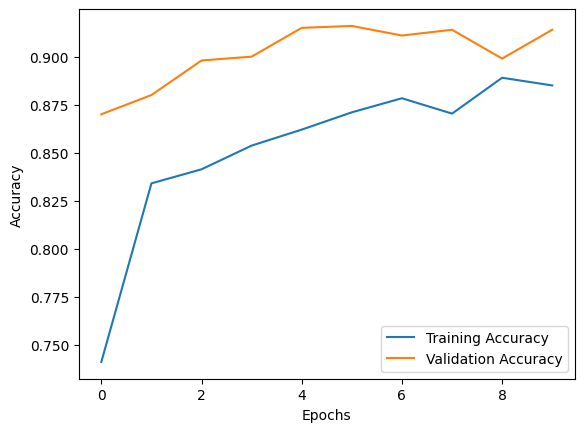

In [53]:
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label = "Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()